# 实验一：Gymnasium 强化学习环境入门

## CartPole

一个连杆通过轴心（pivot point）连接在一个可以在无摩擦轨道上左右移动的小车上。连杆初始状态是基本垂直立起的。目标：通过给小车施加向左或向右的力，保持连杆向上竖立而不倒下，同时避免小车滑出轨道边缘。

终止条件：连杆倾斜角度超过 ±12°或小车位置偏离中心超过 ±2.4 个单位或坚持达到 500 个时间步。

## 实验目标

1. 安装并检查 Gymnasium、NumPy、Matplotlib。
2. 创建 Gymnasium 经典控制环境，理解 `reset()` 与 `step()`。
3. 运行随机策略和一个手写策略。
4. 使用 Matplotlib 可视化回报、回合长度、动作分布和状态轨迹。

本实验默认使用 `CartPole-v1` 作为入门案例；后续可以把 `ENV_ID` 替换成其他 Gymnasium 环境。

## 提交要求

- 完成所有 `TODO` 填空。
- 保留图表输出。
- 在最后写出随机策略与手写策略的表现差异。


## 0. 安装依赖


## 0.1 安装 Miniconda 或 Anaconda

本课程建议使用 Conda 管理 Python 环境。Miniconda 更轻量，Anaconda 会预装更多科学计算包；二者任选其一即可。

### 方式 A：安装 Miniconda（推荐）

1. 访问官方页面下载对应系统安装包：[Miniconda installer](https://docs.conda.io/en/latest/miniconda.html)。
2. 按安装器提示完成安装。
3. 重新打开终端，检查 Conda 是否可用：

```bash
conda --version
```

### 方式 B：安装 Anaconda

1. 访问官方页面下载对应系统安装包：[Anaconda Distribution](https://www.anaconda.com/download)。
2. 按安装器提示完成安装。
3. 重新打开终端，检查 Conda 是否可用：

```bash
conda --version
```

### 创建课程环境

推荐统一使用 Python 3.11：

```bash
conda create -n rl-course python=3.11 -y
conda activate rl-course
python -m pip install -U pip
python -m pip install -U "numpy>=1.26,<2.5" matplotlib ipython "gymnasium[classic-control]"
```

如果需要在 Jupyter Notebook 或 JupyterLab 中选择该环境作为 kernel，可以继续安装：

```bash
python -m pip install -U ipykernel jupyterlab
python -m ipykernel install --user --name rl-course --display-name "Python (rl-course)"
```

如果使用 Python 3.12，可以把 NumPy 约束放宽为最新版：

```bash
python -m pip install -U numpy matplotlib ipython "gymnasium[classic-control]"
```


## Python 版本依赖说明

建议课程统一使用 **Python 3.11**。依据当前 PyPI 包元数据：

- `gymnasium` 1.3.0: `Requires-Python >=3.10`
- `torch` 2.12.1: `Requires-Python >=3.10`
- `ale-py` 0.12.0: `Requires-Python >=3.10`
- `AutoROM` 0.6.1: `Requires-Python >=3.7`
- `matplotlib` 3.11.0: `Requires-Python >=3.11`
- `ipython` 9.15.0: `Requires-Python >=3.11`
- `numpy` 2.5.0: `Requires-Python >=3.12`

因此：

- 若使用 Python 3.11，建议安装 `numpy<2.5`，例如 `numpy>=1.26,<2.5`。
- 若使用 Python 3.12，也可以直接安装最新版 NumPy。
- 不建议使用 Python 3.9 或更低版本；Gymnasium、PyTorch、Atari 相关包的新版本已经不再覆盖。

环境创建命令见上一节；这里主要说明包版本与 Python 版本的兼容关系。


In [1]:
# Python 3.11 推荐安装命令：
# %pip install -U "numpy>=1.26,<2.5" matplotlib ipython "gymnasium[classic-control]"

# Python 3.12 也可以使用最新版 NumPy：
# %pip install -U numpy matplotlib ipython "gymnasium[classic-control]"


## 1. 导入依赖


In [2]:
import sys
import numpy as np
import matplotlib.pyplot as plt

try:
    import gymnasium as gym
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "请先运行安装单元：%pip install -U \"gymnasium[classic-control]\""
    ) from exc

try:
    from IPython.display import HTML, display
    from matplotlib import animation
except Exception:
    HTML = None
    display = None
    animation = None

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)
print("Python:", sys.version.split()[0])
print("Gymnasium:", gym.__version__)


Python: 3.11.15
Gymnasium: 1.3.0


## 2. 创建环境并查看空间



- `gym.make(ENV_ID, render_mode=RENDER_MODE)`：按名字创建一个环境实例。`render_mode` 决定是否画图。
- `env.reset(seed=SEED)`：重置环境到一个初始状态，返回 `(obs, info)`。`obs` 是初始观测，`info` 是附加信息（一般是个空字典）。
- ` (observation_space)`：环境每一步告诉智能体什么信息。CartPole 的观测是一个长度为 4 的向量：`[小车位置 x, 小车速度 x_dot, 杆子角度 theta, 杆子角速度 theta_dot]`, 返回上下界。
- **动作空间 (action_space)**：智能体可以做什么。CartPole 是 `Discrete(2)`，即 `0=向左推`、`1=向右推`。






In [3]:
ENV_ID = "CartPole-v1"
SEED = 42

# TODO 1：填写 render_mode。
# RENDER_MODE = ______  # 可选：None, "rgb_array", "human"
RENDER_MODE = None

env = gym.make(ENV_ID, render_mode=RENDER_MODE)
obs, info = env.reset(seed=SEED)
print("observation_space:", env.observation_space)
print("action_space:", env.action_space)
print("initial obs:", obs)
print("info:", info)
env.close()


observation_space: Box([-4.8       -inf -0.4189    -inf], [4.8       inf 0.4189    inf], (4,), float32)
action_space: Discrete(2)
initial obs: [ 0.0274 -0.0061  0.0359  0.0197]
info: {}


## 3. 单步交互


In [4]:
env = gym.make(ENV_ID)
obs, info = env.reset(seed=SEED)

# TODO 2：从动作空间采样一个动作。
# action = env.action_space.______()
action = env.action_space.sample()

next_obs, reward, terminated, truncated, info = env.step(action)
print("obs:", obs)                      # s_t
print("action:", action)                # a_t
print("next_obs:", next_obs)            # s_t+1
print("reward:", reward)                # r_t
print("terminated:", terminated)        #自然结束，
print("truncated:", truncated)          #外部截断，达到最大步数
print("done:", terminated or truncated)
env.close()


obs: [ 0.0274 -0.0061  0.0359  0.0197]
action: 1
next_obs: [ 0.0273  0.1885  0.0363 -0.2614]
reward: 1.0
terminated: False
truncated: False
done: False


## 4. 可视化工具


In [5]:
# 滑动平均
def moving_average(values, window=20):
    values = np.asarray(values, dtype=np.float32)
    if len(values) == 0:
        return values
    window = max(1, int(window))
    if len(values) < window:
        return np.full_like(values, values.mean())
    kernel = np.ones(window, dtype=np.float32) / window
    prefix = np.full(window - 1, values[:window].mean(), dtype=np.float32)
    return np.concatenate([prefix, np.convolve(values, kernel, mode="valid")])

# 绘制returns，原始回报以及一个窗口内的平均
def plot_returns(returns, lengths=None, window=20, title="Episode return"):
    returns = np.asarray(returns, dtype=np.float32)
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(returns, color="#4C78A8", alpha=0.28, label="raw")
    ax.plot(moving_average(returns, window), color="#F58518", linewidth=2.2, label=f"{window}-episode mean")
    ax.set_title(title)
    ax.set_xlabel("Episode")
    ax.set_ylabel("Return")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

    if lengths is not None:
        fig, ax = plt.subplots(figsize=(9, 3))
        ax.plot(lengths, color="#54A24B", linewidth=1.5)
        ax.set_title("Episode length")
        ax.set_xlabel("Episode")
        ax.set_ylabel("Steps")
        ax.grid(True, alpha=0.3)
        plt.show()

# 统计所有回合合计选过的动作，作直方图
def plot_action_distribution(actions, title="Action distribution"):
    actions = np.asarray(actions, dtype=np.int64)
    if len(actions) == 0:
        print("没有动作数据可视化。")
        return
    labels, counts = np.unique(actions, return_counts=True)
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.bar([str(x) for x in labels], counts, color="#54A24B")
    ax.set_title(title)
    ax.set_xlabel("Action")
    ax.set_ylabel("Count")
    ax.grid(True, axis="y", alpha=0.3)
    plt.show()

# 把四维观测拆分成四张子图，直观地看状态轨迹是否稳定
def plot_vector_observations(observations, title="Observation trajectory"):
    observations = np.asarray(observations, dtype=np.float32)
    names = [f"obs[{i}]" for i in range(observations.shape[1])]
    fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
    for idx, ax in enumerate(axes.ravel()):
        ax.plot(observations[:, idx], linewidth=1.6)
        ax.set_title(names[idx])
        ax.set_xlabel("Step")
        ax.grid(True, alpha=0.3)
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

# 把RGB帧拼成动画在notebook播放，没装IPython/animation则跳过
def show_frames(frames, interval=60):
    if not frames:
        print("没有采集到帧。")
        return None
    if animation is None or HTML is None:
        print("当前环境不支持 notebook 动画显示。")
        return None
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.axis("off")
    image = ax.imshow(frames[0])

    def update(frame):
        image.set_data(frame)
        return (image,)

    ani = animation.FuncAnimation(fig, update, frames=frames, interval=interval, blit=True)
    plt.close(fig)
    return HTML(ani.to_jshtml())


## 5. 运行策略


In [8]:
# 随机采样a_t
def random_policy(obs, env):
    return env.action_space.sample()

# 1_episode
def run_episode(policy_fn, seed=0, max_steps=500, render_mode=None, collect_frames=False):
    env = gym.make(ENV_ID, render_mode=render_mode)
    obs, info = env.reset(seed=seed)

    observations = [np.asarray(obs, dtype=np.float32)]
    actions, rewards, frames = [], [], []

    for step in range(max_steps):
        if collect_frames and render_mode == "rgb_array":  # 播放动画
            frame = env.render()
            if frame is not None:
                frames.append(frame)

        action = int(policy_fn(obs, env))    # f(obs, env) -> action
        next_obs, reward, terminated, truncated, info = env.step(action)
        
        actions.append(action)
        rewards.append(float(reward))
        observations.append(np.asarray(next_obs, dtype=np.float32))
        obs = next_obs
        if terminated or truncated:
            break

    env.close()
    return {
        "return": float(np.sum(rewards)),
        "length": len(rewards),
        "observations": np.asarray(observations),
        "actions": np.asarray(actions),
        "frames": frames,
    }

# n_episode
def evaluate(policy_fn, n_episodes=30, seed=0, title="Policy"):
    episodes = [run_episode(policy_fn, seed=seed + i) for i in range(n_episodes)] # list[dict]
    returns = [x["return"] for x in episodes]
    lengths = [x["length"] for x in episodes]
    print(f"{title}: mean={np.mean(returns):.2f}, std={np.std(returns):.2f}, max={np.max(returns):.1f}")
    plot_returns(returns, lengths, window=max(2, n_episodes // 5), title=title) # returns
    return episodes


## 6. 随机策略基线


在CartPole中每成功走一步reward + 1，所以每个回合step == reward

Random policy: mean=22.60, std=11.75, max=60.0


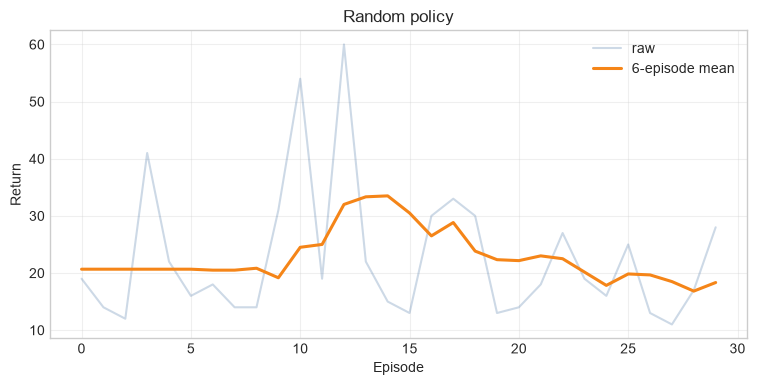

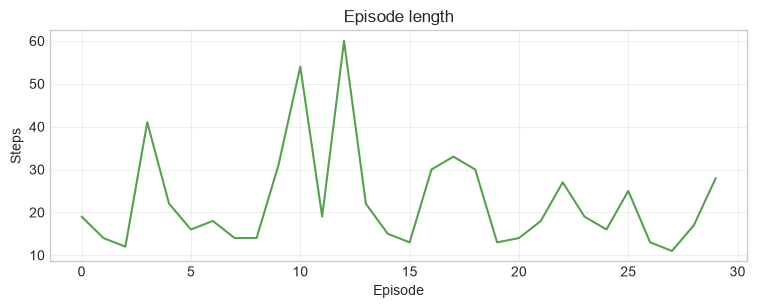

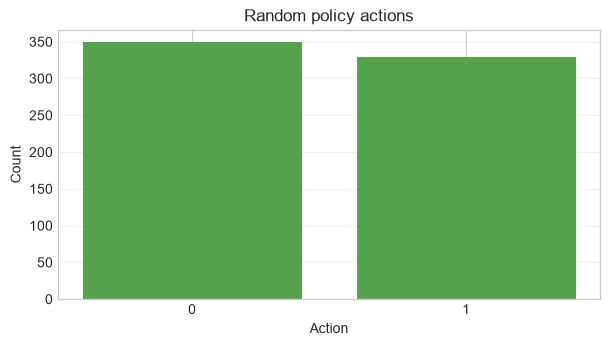

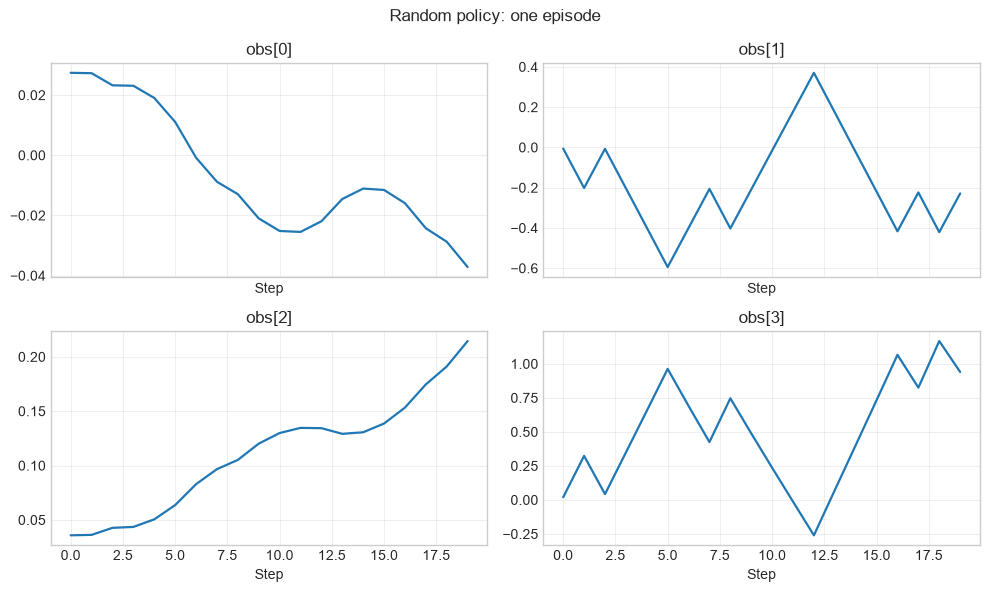

In [9]:
random_episodes = evaluate(random_policy, n_episodes=30, seed=SEED, title="Random policy")
plot_action_distribution(np.concatenate([e["actions"] for e in random_episodes]), "Random policy actions")
plot_vector_observations(random_episodes[0]["observations"], "Random policy: one episode")


## 7. 填空：手写策略


Student policy: mean=40.67, std=10.79, max=62.0


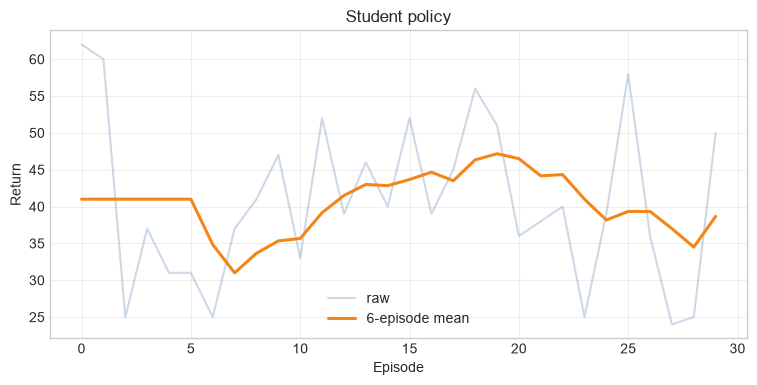

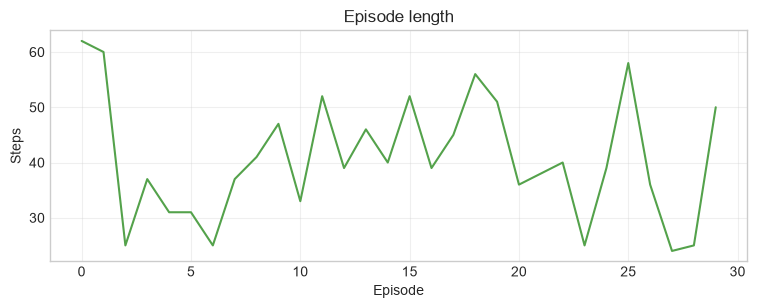

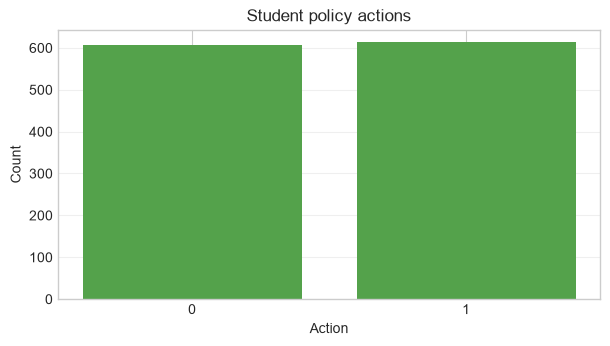

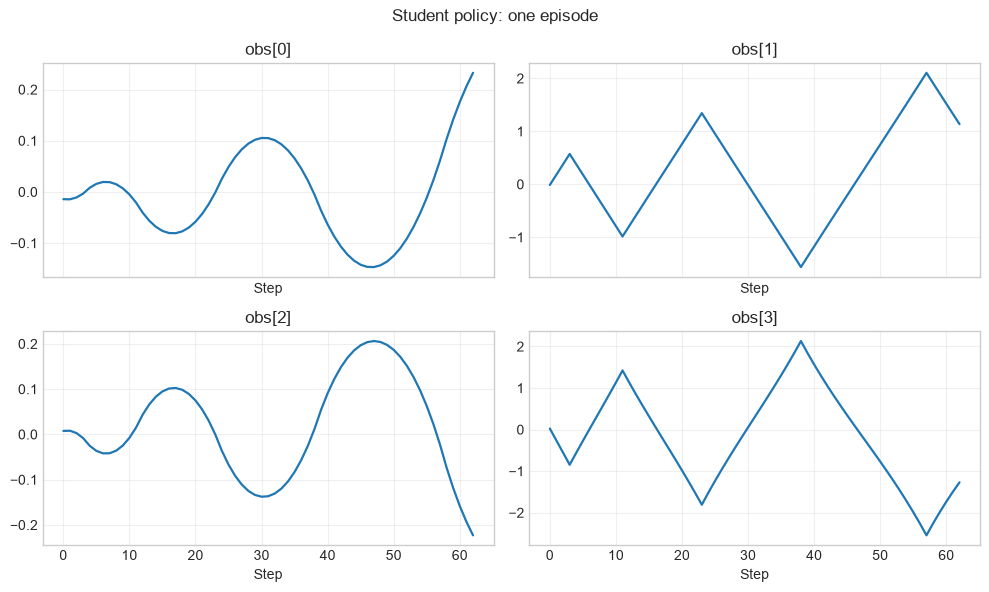

In [10]:
def student_policy(obs, env):
    x, x_dot, theta, theta_dot = obs

    # TODO 3：根据杆子角度 theta 选择动作。
    # 提示：theta > 0 表示杆子向右倾斜，可以尝试向右推。
    # action = 1 if _____ else 0

    action = 1 if theta > 0 else 0
    # 未完成填空前保留随机动作。
    # action = env.action_space.sample()
    return int(action)


student_episodes = evaluate(student_policy, n_episodes=30, seed=SEED + 1000, title="Student policy")
plot_action_distribution(np.concatenate([e["actions"] for e in student_episodes]), "Student policy actions")
plot_vector_observations(student_episodes[0]["observations"], "Student policy: one episode")


## 8. 可选：显示动画


In [11]:
demo = run_episode(student_policy, seed=SEED + 2026, render_mode="rgb_array", collect_frames=True)
html = show_frames(demo["frames"], interval=50)
if html is not None:
    display(html)


## 实验小结

- 随机策略平均回报：
- 手写策略平均回报：
- 状态轨迹中的主要观察：
